In [8]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# PMCW Radar: Phase-Modulated Continuous Wave

## Introduction

**PMCW (Phase-Modulated Continuous Wave) radar** modulates the phase of a constant-frequency carrier using binary code sequences (BPSK) instead of sweeping the frequency like FMCW.

The transmitted signal is:

$$s(t) = A \cos(2\pi f_c t + \phi(t)), \qquad \phi(t) \in \{0°, 180°\}$$

**Range** is extracted from code correlation delay $\tau$:

$$\Delta R = \frac{c \cdot T_{chip}}{2}$$

**Maximum unambiguous velocity** is chip-duration limited:

$$v_{max} = \frac{c}{2 f_c T_{chip}}$$

For 24.125 GHz with $T_{chip} = 4$ ns: $v_{max} \approx 1550$ m/s — far beyond FMCW's typical 30–100 m/s.

### PMCW vs. FMCW

| Feature | FMCW | PMCW |
|---------|------|------|
| Modulation | Frequency chirp | Phase code (BPSK) |
| Range | Beat frequency | Code correlation |
| Max velocity | ~30–100 m/s | ~1550 m/s (chip-limited) |
| Interference | Sensitive | Orthogonal code rejection |
| MIMO | Limited | Code-division multiplexing |
| Sampling rate | ~MHz (beat freq) | ~250 MHz (chip rate) |

### This Example

Uses `RadarSimPy` to simulate a 2-channel MIMO PMCW radar:

- **Carrier**: 24.125 GHz, 255-chip binary codes at 4 ns/chip (1.02 μs)
- **MIMO**: TX1 at (0, 0, 0) m and TX2 at (1, 0, 0) m with orthogonal codes
- **256 pulses** for Doppler processing
- **3 targets**: −200 m/s at 20 m, 0 m/s at 70 m, +100 m/s at ~34 m
- **Processing**: matched filtering → MIMO channel separation → range-Doppler maps

## Phase Code Definition

Define binary BPSK phase code sequences for both MIMO channels.

In [9]:
import numpy as np
import plotly.graph_objs as go
from IPython.display import Image, display
from radarsimpy import Radar, Transmitter, Receiver
from radarsimpy.simulator import sim_radar
from scipy import signal

INTERACTIVE = False

def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

In [10]:
### Phase Code Sequences ###

# Define binary phase code 1 (255 chips)
# Values: +1 or -1 (will be converted to 0° or 180° phase)
code1 = np.array(
    [
        1,  -1, 1,  1,  -1, -1, -1, 1,  -1, 1,  -1, 1,  1,  1,  -1, 1,  1,
        -1, -1, 1,  1,  1,  -1, -1, -1, -1, 1,  -1, -1, 1,  -1, -1, 1,  1,
        1,  1,  1,  -1, 1,  1,  1,  -1, -1, 1,  -1, 1,  1,  -1, 1,  -1, -1,
        -1, -1, -1, 1,  1,  -1, 1,  -1, 1,  -1, -1, 1,  -1, -1, -1, 1,  1,
        -1, -1, 1,  -1, 1,  -1, 1,  1,  -1, -1, -1, -1, 1,  1,  1,  1,  -1,
        -1, 1,  1,  -1, 1,  1,  1,  1,  -1, -1, -1, 1,  -1, -1, -1, -1, -1,
        -1, 1,  -1, 1,  1,  1,  1,  1,  1,  -1, -1, 1,  -1, -1, 1,  1,  -1,
        -1, -1, -1, 1,  -1, -1, -1, -1, 1,  -1, 1,  -1, -1, 1,  1,  -1, -1,
        1,  1,  1,  -1, 1,  -1, 1,  1,  1,  -1, 1,  1,  1,  1,  1,  1,  1,
        -1, 1,  -1, -1, -1, 1,  -1, 1,  1,  -1, -1, 1,  1,  -1, 1,  -1, -1,
        1,  -1, 1,  1,  -1, 1,  1,  -1, -1, -1, 1,  -1, -1, 1,  -1, 1,  1,
        1,  -1, -1, -1, 1,  1,  1,  1,  1,  -1, 1,  -1, 1,  -1, 1,  -1, -1,
        -1, -1, 1,  1,  -1, 1,  1,  1,  -1, 1,  1,  -1, 1,  -1, -1, -1, 1,
        1,  1,  -1, -1, 1,  -1, -1, -1, 1,  -1, 1,  -1, 1,  -1, 1,  1,  1,
        1,  -1, 1,  1,  -1, 1,  -1, 1,  -1, -1, -1, -1, -1, 1,  -1, -1, 1,
    ]
)

# Define binary phase code 2 (255 chips, orthogonal to code1)
code2 = np.array(
    [
        1,  1,  1,  -1, -1, -1, -1, 1,  1,  -1, -1, 1,  -1, 1,  1,  -1, -1,
        1,  -1, 1,  -1, -1, 1,  -1, -1, 1,  1,  -1, 1,  1,  -1, 1,  -1, -1,
        -1, 1,  -1, 1,  1,  1,  1,  1,  -1, 1,  1,  1,  -1, -1, 1,  1,  -1,
        1,  1,  -1, -1, -1, -1, -1, -1, 1,  -1, 1,  1,  1,  1,  1,  1,  -1,
        -1, 1,  -1, -1, 1,  1,  -1, -1, -1, -1, 1,  -1, -1, -1, -1, 1,  -1,
        1,  -1, -1, 1,  1,  -1, -1, 1,  1,  1,  -1, 1,  -1, 1,  1,  1,  -1,
        1,  1,  1,  1,  1,  1,  1,  -1, 1,  -1, -1, -1, 1,  -1, 1,  1,  -1,
        1,  -1, -1, -1, 1,  1,  -1, -1, 1,  -1, 1,  -1, 1,  1,  -1, -1, -1,
        -1, 1,  1,  1,  1,  -1, -1, 1,  1,  -1, 1,  1,  1,  -1, 1,  -1, -1,
        1,  -1, 1,  1,  -1, 1,  1,  -1, -1, -1, 1,  -1, -1, 1,  -1, 1,  1,
        1,  -1, 1,  -1, 1,  -1, -1, -1, -1, 1,  1,  -1, 1,  1,  1,  -1, 1,
        1,  -1, 1,  -1, -1, -1, 1,  1,  1,  -1, -1, 1,  -1, -1, -1, 1,  -1,
        1,  1,  -1, -1, 1,  1,  -1, 1,  -1, -1, 1,  -1, -1, -1, -1, -1, 1,
        1,  -1, 1,  -1, 1,  -1, -1, 1,  -1, -1, -1, 1,  1,  -1, -1, 1,  -1,
        1,  -1, 1,  1,  1,  -1, 1,  1,  1,  1,  -1, -1, -1, 1,  -1, -1, 1,
    ]
)

# Convert ±1 binary codes to phase (degrees): +1 → 0°, -1 → 180°
phase_code1 = np.where(code1 > 0, 0, 180)   # TX channel 1 phase sequence
phase_code2 = np.where(code2 > 0, 0, 180)   # TX channel 2 phase sequence

# Define chip duration and timing
chip_duration = 4e-9  # 4 ns per chip

# Create time arrays for phase modulation (one entry per chip transition)
t_mod1 = np.arange(0, 255) * chip_duration  # 255 chip times for TX1
t_mod2 = np.arange(0, 255) * chip_duration  # 255 chip times for TX2

### Visualize Phase Code Sequences

Display phase modulation sequences for both MIMO channels showing BPSK modulation pattern.

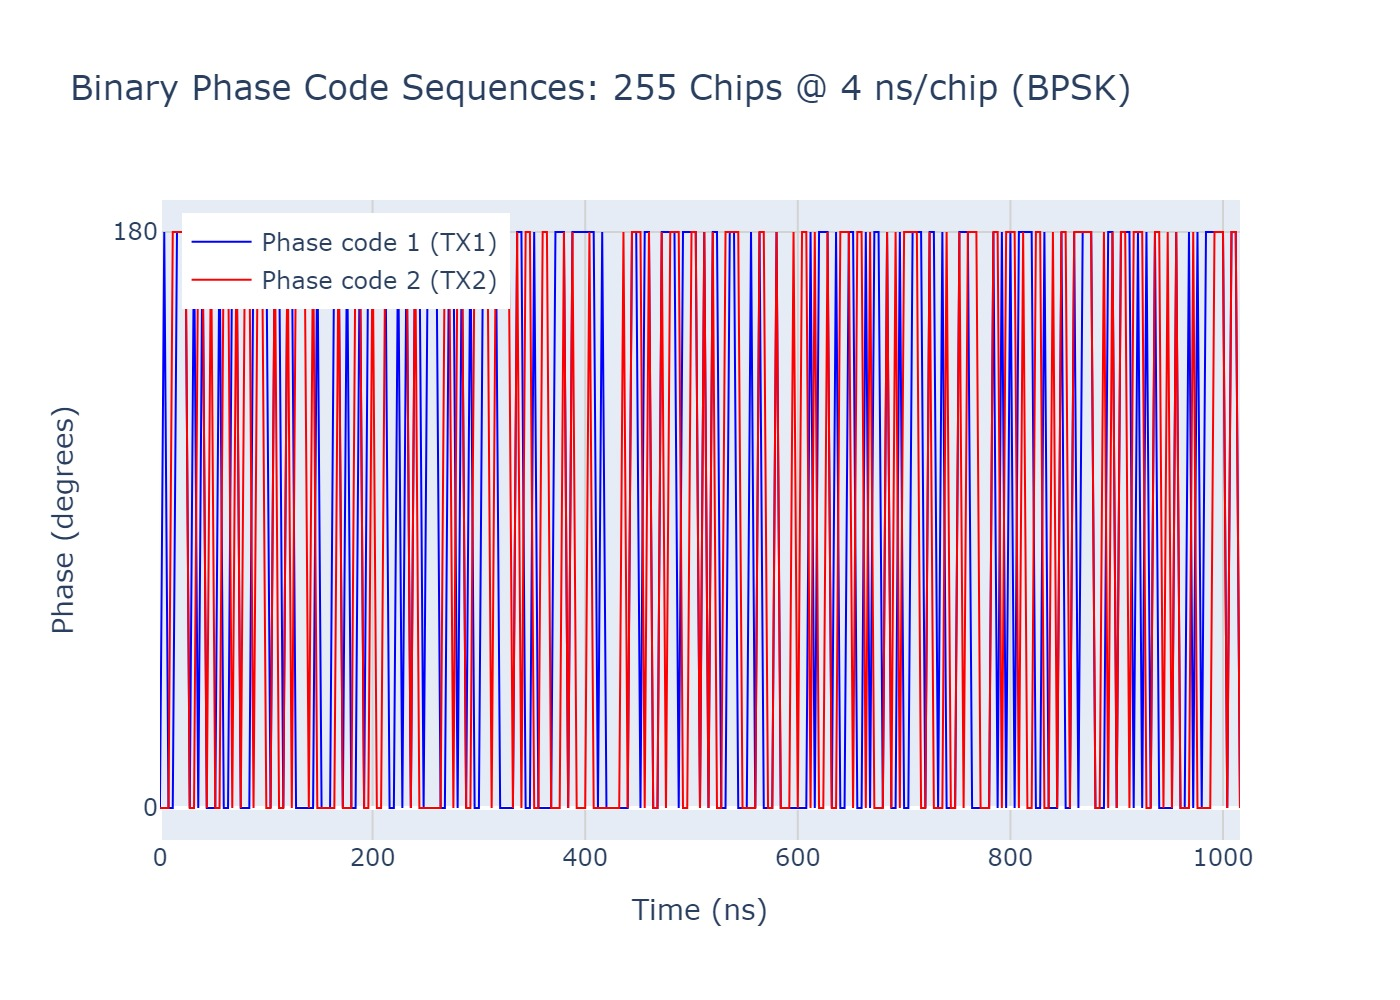

In [11]:
# Create figure for phase code visualization
fig = go.Figure()

# Plot phase code sequence 1 (TX channel 1)
fig.add_trace(
    go.Scatter(
        x=t_mod1 * 1e9,           # Convert to nanoseconds
        y=phase_code1,            # Phase in degrees
        name="Phase code 1 (TX1)",
        line=dict(color='blue', width=1),
        mode='lines',
    )
)

# Plot phase code sequence 2 (TX channel 2)
fig.add_trace(
    go.Scatter(
        x=t_mod2 * 1e9,           # Convert to nanoseconds
        y=phase_code2,            # Phase in degrees
        name="Phase code 2 (TX2)",
        line=dict(color='red', width=1),
        mode='lines',
    )
)

# Configure plot layout
fig.update_layout(
    title="Binary Phase Code Sequences: 255 Chips @ 4 ns/chip (BPSK)",
    yaxis=dict(
        title="Phase (degrees)",
        gridcolor='lightgray',
        tickvals=[0, 180],  # Only show 0° and 180°
    ),
    xaxis=dict(title="Time (ns)", gridcolor='lightgray'),
    height=500,
    legend=dict(x=0.02, y=0.98),
)

show(fig)

## Radar System Configuration

### Transmitter Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| Carrier frequency | 24.125 GHz | Constant — no frequency modulation |
| Pulse duration | 2.1 μs | Code (1.02 μs) + guard time |
| Transmit power | 20 dBm | ~100 mW |
| Pulses | 256 | For Doppler processing |
| TX1 location | (0, 0, 0) m | Phase code 1 |
| TX2 location | (1, 0, 0) m | Phase code 2 (orthogonal), 1 m spacing |

Both channels transmit **simultaneously** at the same carrier frequency; orthogonal codes enable receiver-side separation via matched filtering.

In [12]:
### Define TX Channel 1 with Phase Code 1 ###
tx_channel_1 = dict(
    location=(0, 0, 0),     # TX1 antenna position at origin
    mod_t=t_mod1,           # Phase modulation timing (255 points × 4 ns)
    phs=phase_code1,        # Phase sequence for channel 1 (0° or 180°)
)

### Define TX Channel 2 with Phase Code 2 ###
tx_channel_2 = dict(
    location=(1, 0, 0),     # TX2 antenna position 1m offset in X
    mod_t=t_mod2,           # Phase modulation timing (same as TX1)
    phs=phase_code2,        # Phase sequence for channel 2 (orthogonal code)
)

### Create PMCW Transmitter ###
tx = Transmitter(
    f=24.125e9,             # Carrier frequency: 24.125 GHz (constant, no chirp)
    t=2.1e-6,               # Pulse duration: 2.1 μs (includes code + guard time)
    tx_power=20,            # Transmit power: 20 dBm (~100 mW)
    pulses=256,             # Number of pulses: 256 (for Doppler processing)
    channels=[tx_channel_1, tx_channel_2],  # 2-channel MIMO configuration
)

### Receiver Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| Sampling rate | 250 MHz | 4 ns/sample — matches chip duration |
| Noise figure | 10 dB | — |
| RF gain | 20 dB | — |
| Baseband gain | 30 dB | Total: 50 dB |
| Load resistor | 1000 Ω | — |
| Location | (0, 0, 0) m | Monostatic with TX1 |

PMCW requires a **much higher sampling rate** than FMCW because phase transitions (4 ns chips) must be captured directly, unlike FMCW which samples only the beat frequency (~MHz).

In [13]:
# Configure PMCW radar receiver
rx = Receiver(
    fs=250e6,            # Sampling rate: 250 MHz (4 ns per sample, matches chip rate)
    noise_figure=10,     # Noise figure: 10 dB
    rf_gain=20,          # RF gain: 20 dB
    baseband_gain=30,    # Baseband gain: 30 dB (total: 50 dB)
    load_resistor=1000,  # Load resistance: 1000 Ω
    channels=[dict(location=(0, 0, 0))],  # Single RX at origin
)

### Create Radar System

Combine transmitter and receiver to form the complete PMCW MIMO radar.

In [14]:
# Create complete PMCW MIMO radar system
radar = Radar(transmitter=tx, receiver=rx)

## Target Configuration

Three targets with velocities that exceed typical FMCW capability ($v_{max,FMCW} \approx 30$–100 m/s):

| Target | Range | Velocity | RCS | Notes |
|--------|-------|----------|-----|-------|
| 1 | 20 m | −200 m/s | 10 dBsm | Approaching at 720 km/h |
| 2 | 70 m | 0 m/s | 35 dBsm | Stationary (large) |
| 3 | ~34 m | +100 m/s | 20 dBsm | Receding at 360 km/h |

All targets are within PMCW's $v_{max} \approx 1550$ m/s without Doppler ambiguity.

In [15]:
# Configure Target 1: Very high closing speed (beyond FMCW capability)
target_1 = dict(
    location=(20, 0, 0),    # Position: 20m range
    speed=(-200, 0, 0),     # Velocity: -200 m/s (720 km/h approaching!)
    rcs=10,                 # Radar cross section: 10 dBsm
    phase=0,                # Initial phase: 0 degrees
)

# Configure Target 2: Stationary, large RCS (reference)
target_2 = dict(
    location=(70, 0, 0),    # Position: 70m range
    speed=(0, 0, 0),        # Velocity: 0 m/s (stationary)
    rcs=35,                 # Radar cross section: 35 dBsm (very large)
    phase=0,                # Initial phase: 0 degrees
)

# Configure Target 3: High receding speed
target_3 = dict(
    location=(33, 10, 0),   # Position: ~34m range, 10m Y-offset
    speed=(100, 0, 0),      # Velocity: +100 m/s (360 km/h receding)
    rcs=20,                 # Radar cross section: 20 dBsm
    phase=0,                # Initial phase: 0 degrees
)

# Combine targets for simulation
targets = [target_1, target_2, target_3]

## Simulate Baseband Signals

Simulate PMCW baseband I/Q from both MIMO TX channels. Output shape: `[2 TX channels, 256 pulses, ~525 samples/pulse]`.

In [16]:
# Simulate PMCW radar with 2-channel MIMO and three high-velocity targets
data = sim_radar(radar, targets)

# Extract timestamp and baseband signals
timestamp = data["timestamp"]                       # Time axis [2, 256, 525]
data_matrix = data["baseband"] + data["noise"]     # Complex I/Q + noise [2, 256, 525]

### Combine Simultaneous TX Channels

In hardware, TX1 and TX2 transmit simultaneously — the RX receives their superposition. Sum both channel contributions to form the combined baseband `[256 pulses, ~525 samples]` before matched filtering.

In [17]:
# Combine baseband from both TX channels (simultaneous transmission)
# TX1 and TX2 signals are received together at RX
baseband = data_matrix[0, :, :] + data_matrix[1, :, :]  # [256 pulses, 525 samples]

### Visualize Combined Baseband

Display time-domain I/Q signals showing superposition of both phase-coded TX channels.

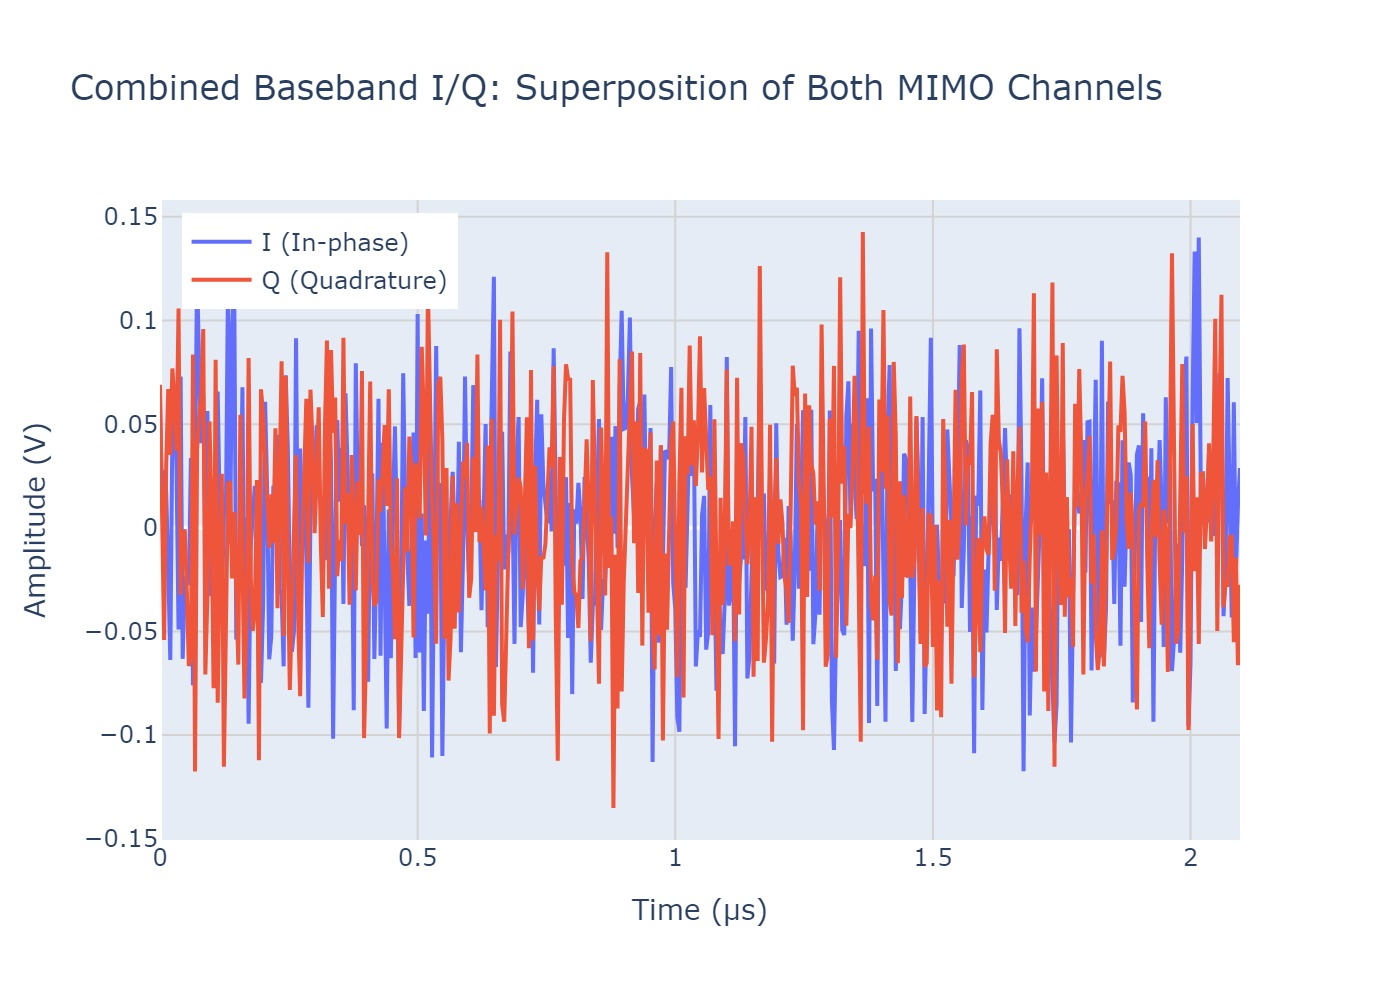

In [24]:
# Create figure for combined baseband visualization
fig = go.Figure()

# Plot In-phase (I) component of first pulse
fig.add_trace(
    go.Scatter(
        x=timestamp[0, 0, :] * 1e6,     # Convert to microseconds
        y=np.real(baseband[0, :]),      # Real part (I channel)
        name="I (In-phase)",
    )
)

# Plot Quadrature (Q) component of first pulse
fig.add_trace(
    go.Scatter(
        x=timestamp[0, 0, :] * 1e6,     # Convert to microseconds
        y=np.imag(baseband[0, :]),      # Imaginary part (Q channel)
        name="Q (Quadrature)",
    )
)

# Configure plot layout
fig.update_layout(
    title="Combined Baseband I/Q: Superposition of Both MIMO Channels",
    yaxis=dict(title="Amplitude (V)", gridcolor='lightgray'),
    xaxis=dict(title="Time (μs)", gridcolor='lightgray'),
    height=500,
    legend=dict(x=0.02, y=0.98),
)

show(fig)

## Radar Signal Processing

### Matched Filtering (Code Correlation)

Range is extracted by correlating the received signal with each code:

$$R[n] = \sum_{k=0}^{N-1} s[k] \cdot c^*[k-n]$$

Due to low cross-correlation between orthogonal codes, correlating with `code1` extracts TX1's contribution and `code2` extracts TX2's — separating the two MIMO channels. Result: range profile matrix `[2 channels, 256 pulses, 255 range bins]`.

### Demodulate Channel 1

In [19]:
# Initialize range profile storage
# Dimensions: [2 MIMO channels, 256 pulses, 255 range bins]
range_profile = np.zeros(
    (
        radar.array_prop["size"],  # 2 TX channels (MIMO)
        radar.radar_prop["transmitter"].waveform_prop["pulses"],  # 256 pulses
        255,  # 255 range bins (one per chip offset)
    ),
    dtype=complex,  # Complex I/Q data
)

### Matched Filtering for Channel 1 (TX1 with code1) ###

# Loop over all pulses
for pulse_idx in range(0, radar.radar_prop["transmitter"].waveform_prop["pulses"]):
    # Loop over all range bins (delay offsets)
    for bin_idx in range(0, 255):
        # Correlate received signal with code1
        # Extract 255 samples starting at bin_idx
        # Multiply element-wise with code1 and sum (correlation)
        range_profile[0, pulse_idx, bin_idx] = np.sum(
            code1 * baseband[pulse_idx, bin_idx : (bin_idx + 255)]
        )

### Demodulate Channel 2

Correlate with code2 to extract TX channel 2 contribution.

In [20]:
### Matched Filtering for Channel 2 (TX2 with code2) ###

# Loop over all pulses
for pulse_idx in range(0, radar.radar_prop["transmitter"].waveform_prop["pulses"]):
    # Loop over all range bins (delay offsets)
    for bin_idx in range(0, 255):
        # Correlate received signal with code2
        # Orthogonal code extracts TX2 contribution
        range_profile[1, pulse_idx, bin_idx] = np.sum(
            code2 * baseband[pulse_idx, bin_idx : (bin_idx + 255)]
        )

### Visualize Range Profiles

Display averaged range profiles for both MIMO channels showing target detection.

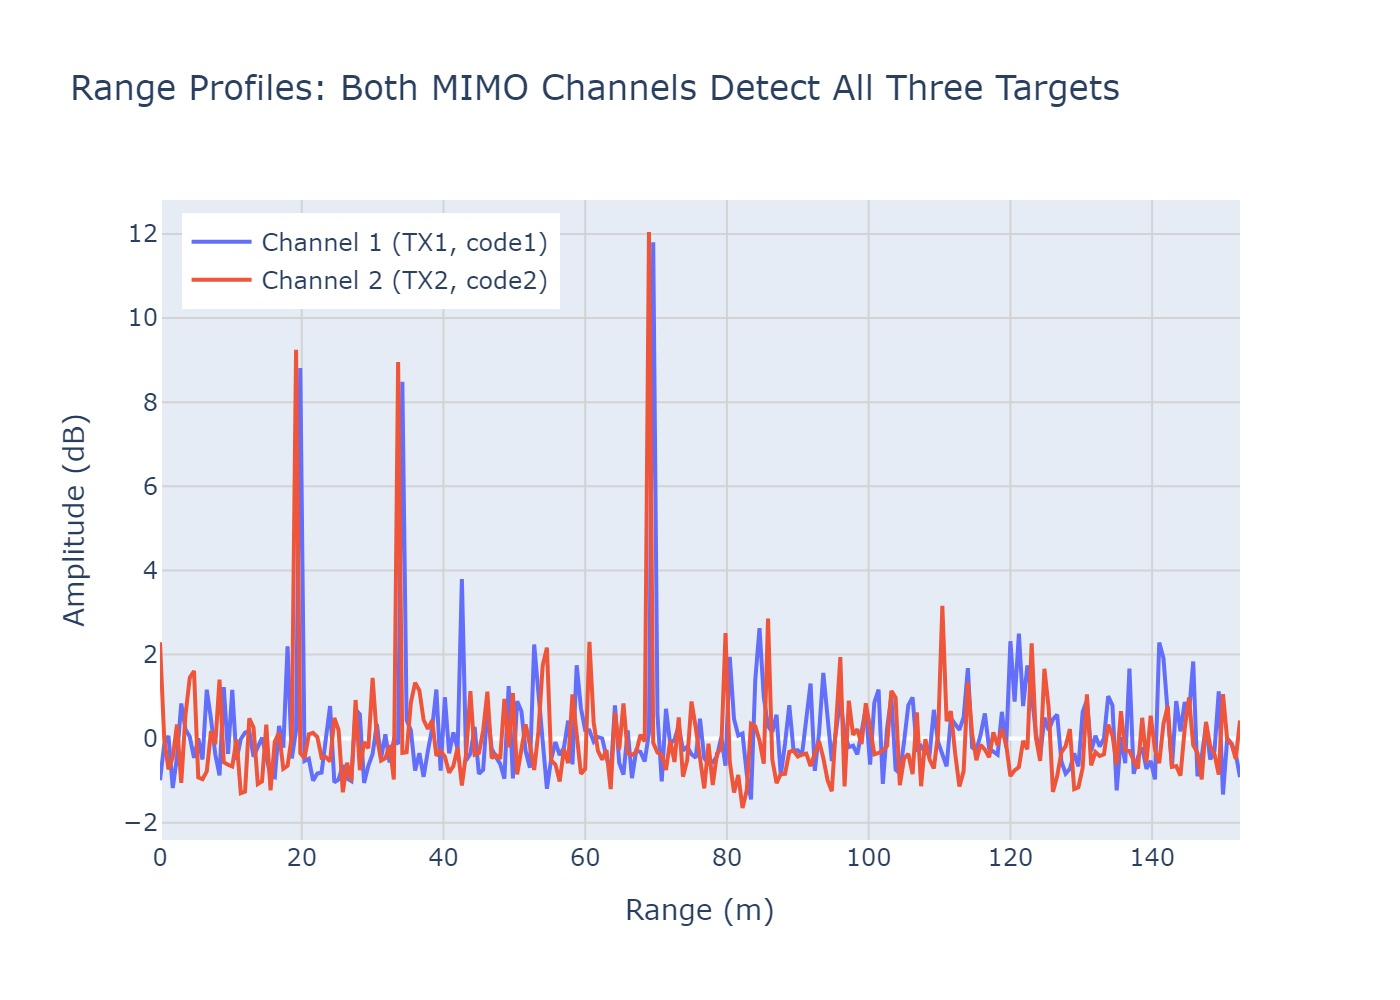

In [21]:
# Calculate range bin size
# Range resolution = c / 2 × chip_duration
bin_size = 3e8 / 2 * 4e-9  # Speed of light / 2 × 4 ns = 0.6 m per bin

# Create range axis
range_bin = np.arange(0, 255, 1) * bin_size  # 255 bins × 0.6 m

# Create comparison figure
fig = go.Figure()

# Plot Channel 1 range profile (averaged over all pulses)
fig.add_trace(
    go.Scatter(
        x=range_bin,
        y=20 * np.log10(np.mean(np.abs(range_profile[0, :, :]), axis=0)),
        name="Channel 1 (TX1, code1)",
    )
)

# Plot Channel 2 range profile (averaged over all pulses)
fig.add_trace(
    go.Scatter(
        x=range_bin,
        y=20 * np.log10(np.mean(np.abs(range_profile[1, :, :]), axis=0)),
        name="Channel 2 (TX2, code2)",
    )
)

# Configure plot layout
fig.update_layout(
    title="Range Profiles: Both MIMO Channels Detect All Three Targets",
    yaxis=dict(title="Amplitude (dB)", gridcolor='lightgray'),
    xaxis=dict(title="Range (m)", gridcolor='lightgray'),
    height=500,
    legend=dict(x=0.02, y=0.98),
)

show(fig)

### Doppler Processing

Apply Chebyshev-windowed FFT across pulses for each range bin:

$$v_{max} = \frac{c}{2 f_c \cdot PRP}$$

A 50-dB Chebyshev window suppresses sidelobes before the 256-point FFT. Result: range-Doppler map `[2 channels, 256 Doppler bins, 255 range bins]`.

In [22]:
# Create Chebyshev window for Doppler FFT (50 dB sidelobe suppression)
doppler_window = signal.windows.chebwin(
    radar.radar_prop["transmitter"].waveform_prop["pulses"], at=50
)

# Initialize range-Doppler map storage
# Dimensions: [2 MIMO channels, 256 Doppler bins, 255 range bins]
range_doppler = np.zeros(np.shape(range_profile), dtype=complex)

# Perform Doppler FFT for each channel and range bin
for ii in range(0, radar.array_prop["size"]):  # Loop over MIMO channels (2)
    for jj in range(0, 255):  # Loop over range bins (255)
        # Apply window, FFT, and shift for each range bin
        range_doppler[ii, :, jj] = np.fft.fftshift(
            np.fft.fft(
                range_profile[ii, :, jj] * doppler_window,  # Window across pulses
                n=radar.radar_prop["transmitter"].waveform_prop["pulses"],  # 256-point FFT
            )
        )

# Calculate maximum unambiguous velocity
# v_max = c / (2 * f_c * PRP)
unambiguous_speed = (
    3e8  # Speed of light
    / radar.radar_prop["transmitter"].waveform_prop["prp"]  # Pulse repetition period
    / 24.125e9  # Carrier frequency
    / 2  # Two-way Doppler
)

### Visualize Range-Doppler Map

Display 3D range-Doppler map for Channel 1 showing high-velocity targets.

**Interpretation:**

- **X-axis**: Range (m) → Target distance
- **Y-axis**: Velocity (m/s) → Radial velocity (negative = approaching, positive = receding)
- **Z-axis**: Amplitude (dB) → Detection strength
- **Peaks**: Three targets at their (range, velocity) coordinates

**Expected Targets:**

1. **Target 1**: ~20m, -200 m/s (very high closing speed)
2. **Target 2**: ~70m, 0 m/s (stationary)
3. **Target 3**: ~33m, +100 m/s (high receding speed)

**PMCW Advantage:**

All three targets are clearly resolved despite extreme velocities (±200 m/s) that would cause severe Doppler ambiguity in typical FMCW radar.

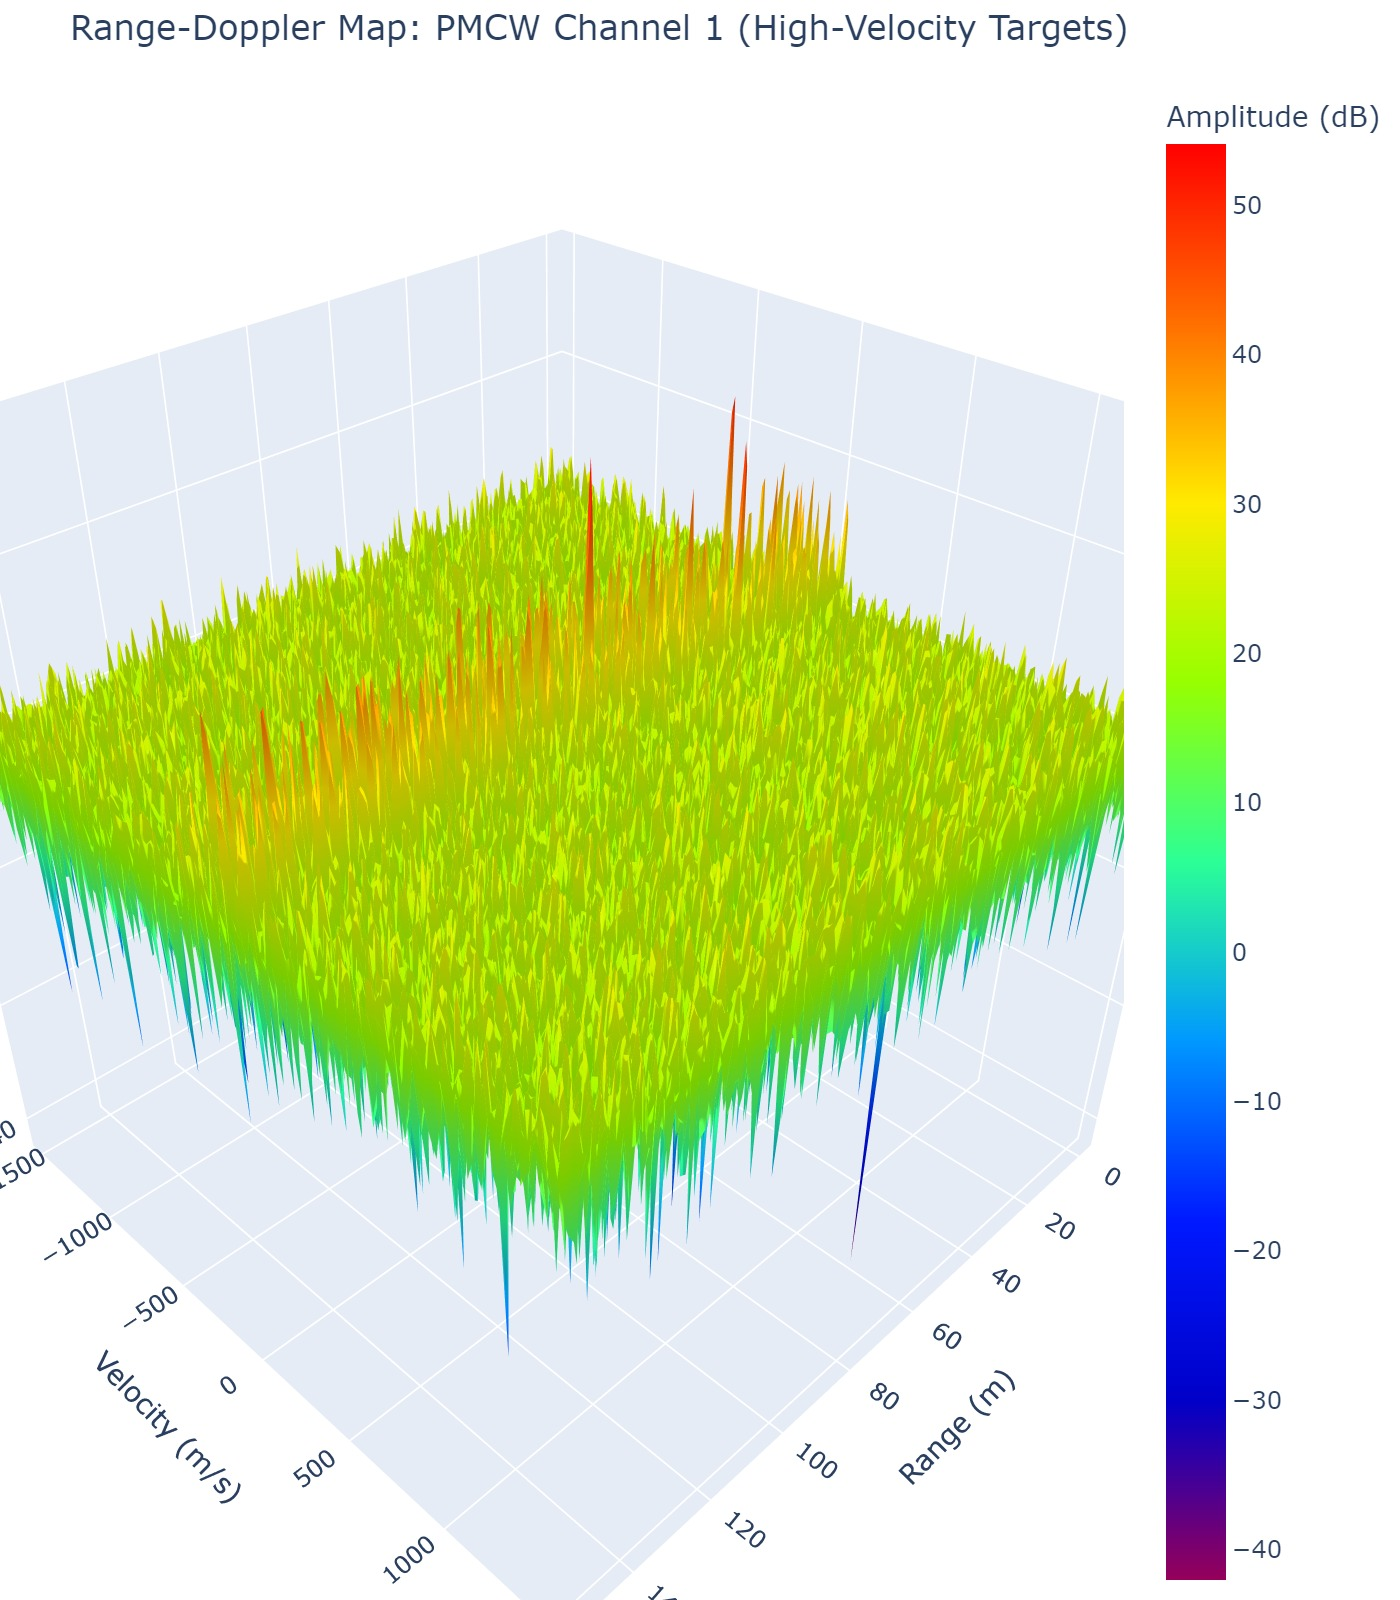

In [23]:
# Create range axis (same as before)
range_axis = np.arange(0, 255, 1) * bin_size  # 0 to ~153 m

# Create velocity axis (centered around zero)
doppler_axis = np.linspace(
    -unambiguous_speed / 2,  # Maximum approaching velocity
    unambiguous_speed / 2,   # Maximum receding velocity
    radar.radar_prop["transmitter"].waveform_prop["pulses"],  # 256 bins
    endpoint=False,
)

# Create 3D surface plot of range-Doppler map (Channel 1)
fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=range_axis,                                  # Range axis (m)
        y=doppler_axis,                                # Velocity axis (m/s)
        z=20 * np.log10(np.abs(range_doppler[0, :, :])),  # Amplitude (dB) for channel 1
        colorscale="Rainbow",                          # Color scheme
        colorbar=dict(title="Amplitude (dB)"),
    )
)

# Configure 3D plot layout
fig.update_layout(
    title="Range-Doppler Map: PMCW Channel 1 (High-Velocity Targets)",
    height=800,
    scene=dict(
        xaxis=dict(title="Range (m)"),
        yaxis=dict(title="Velocity (m/s)"),
        zaxis=dict(title="Amplitude (dB)"),
        aspectmode="cube",
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

show(fig)

## Summary

This example demonstrated a 2-channel MIMO PMCW radar with high-velocity target detection:

- **BPSK phase coding** on a constant carrier enables range via code correlation, not beat frequency
- **$v_{max} \approx 1550$ m/s** (chip-limited) far exceeds FMCW's typical 30–100 m/s range
- **Orthogonal codes** allow simultaneous MIMO transmission and receiver-side channel separation
- **250 MHz sampling** required to capture 4 ns chip transitions (much higher than FMCW)
- **Matched filtering** provides range compression with processing gain equal to code length (255)
- **Doppler FFT** across 256 pulses resolves all three targets from −200 m/s to +100 m/s

### Things to Try

| Experiment | What to Change | What to Observe |
|------------|----------------|-----------------|
| Code length | 127 or 511 chips | Range resolution and processing gain |
| Chip duration | 2, 8, 16 ns | Resolution vs. sampling rate |
| Number of pulses | 128, 512 | Velocity resolution vs. update rate |
| Carrier frequency | 77 GHz | Doppler sensitivity ($f_d \propto f_c$) |
| Target velocity | ±500 m/s | $v_{max}$ limits and ambiguity |
| MIMO scaling | 3–4 TX channels | Virtual array size and angular resolution |
| Code selection | Gold, Kasami codes | Cross-correlation and interference rejection |
| Window functions | Hamming, Taylor | Sidelobe vs. resolution trade-off |

### Resources

- [RadarSimPy Documentation](https://radarsimx.com)
- [RadarSimPy Simulator Module](https://radarsimx.github.io/radarsimpy/simulator.html)